<a href="https://colab.research.google.com/github/MGentieu/dl_project/blob/martin_nlp/starters/cv-project-starter/cv-project/notebooks/CV_Caltech-101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entraînement d'un modèle de Computer Vision (CV) avec le dataset Caltech-101

# M1 Définition de l'entrée, de la sortie et des métriques d'évaluation.

On prend en entrée le dataset Caltech-101 afin d'entraîner un modèle de classification d'images.

Afin d'évaluer notre modèle et de sélectionner le meilleur parmi les différentes époques d'entraînement, nous nous intéresserons plus particulièrement **l'exactitude (accuracy) globale sur le dataset de validation.**

Cette métrique est adaptée car notre dataset est bien équilibré.

Nous afficherons cependant d'autres métriques, comme la précision, le rappel ou le score F1 pour le meilleur modèle obtenu.

Nous n'afficherons cependant pas de matrice de confusion, ayant 101 classes différentes à traiter, ce qui rendrait la matrice illisible.


## Data Card — Caltech-101

**Source :** California Institute of Technology  
**Licence :** Creative Commons Attribution (CC-BY)  
**Caractéristiques :** 101 classes, environ 9000 images, objets centrés  
**Biais potentiels :** objets principalement occidentaux, peu de diversité visuelle...

Il a aussi la particularité que certaines images sont grises et ne suivent pas la définition RGB. Cela nécessitera donc une normalisation au moment du chargement des données.

### Datasets de train et de validation

Le dataset sera divisé en deux : un pour l'entraînement, enrichi avec des corruptions et équilibré entre les différentes classe, et un propre pour la validation.


# Connexion à github et setup initial

Pour github : à exécuter dans le terminal de colab

```bash
git clone https://github.com/MGentieu/dl_project.git

### Step 0 — On confirme l'utilisation du GPU



In [1]:
!nvidia-smi || echo "nvidia-smi unavailable (CPU runtime)"

Wed Dec  3 10:36:49 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Step 1 : Installation et importation des bibliothèques

In [2]:
# Install required libraries
!pip -q install torch torchvision torchmetrics==1.4.0 matplotlib tqdm ultralytics datasets scikit-learn

In [3]:
import os
import sys
from pathlib import Path
import yaml
import time
import copy
import torch.nn as nn
import numpy as np
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset, WeightedRandomSampler, Dataset
from torchvision import datasets, models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown
import json
import pandas as pd
import seaborn as sns
import torch
from collections import Counter
import random

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


### Step 2 — Pointer le répertoire du projet


In [4]:
# The user has provided the explicit path to the project root.
PROJECT_ROOT = Path("/content/dl_project/starters/cv-project-starter/cv-project")

print(f"Environment: Colab/Kaggle (remote server), using provided PROJECT_ROOT")

# Validate structure
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError(f"Missing src/ directory at {PROJECT_ROOT}")

# Setup Python path
os.chdir(PROJECT_ROOT)
src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Project root: {PROJECT_ROOT}")
print(f"Working directory: {Path.cwd()}")


Environment: Colab/Kaggle (remote server), using provided PROJECT_ROOT
Project root: /content/dl_project/starters/cv-project-starter/cv-project
Working directory: /content/dl_project/starters/cv-project-starter/cv-project


# M2 : Baseline Model implementation

#### Code basique pour vérifier le bon fonctionnement et le chargement de Caltech-101

In [5]:
import torchvision as tv
tf_train = tv.transforms.Compose([tv.transforms.Resize(224), tv.transforms.RandomHorizontalFlip(), tv.transforms.ToTensor()])
tf_val   = tv.transforms.Compose([tv.transforms.Resize(224), tv.transforms.ToTensor()])
train = tv.datasets.Caltech101(root="./data", download=True, transform=tf_train)
# Create a small validation split:
val_size = int(0.1*len(train)); train, val = torch.utils.data.random_split(train, [len(train)-val_size, val_size])
val.dataset.transform = tf_val
print(len(train), len(val))

100%|██████████| 137M/137M [00:02<00:00, 56.6MB/s]


7810 867


Le chargement du dataset et la transformation basique s'est bien effectuée. On passe donc à l'étape suivante, le chargement réel du dataset et l'exploration des données

On charge dans un premier temps le fichier yaml de configuration

In [6]:
yaml_content = open('configs/cv_caltech101.yaml')

config = yaml.safe_load(yaml_content)

# Création du dossier de sortie
os.makedirs(config['output_dir'], exist_ok=True)

# Configuration du Device (GPU / MPS pour Mac / CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Utilisation du device : {device}")

Utilisation du device : cuda


### On charge maintenant et on explore les données du dataset Caltech-101. Plusieurs étapes :
- Augmentation des données pour l'entraînement (flip, jitter, luminosité, contraste)
- Equilibrage des classes pour l'entraînement et la validation (80% et 20% par class)
- Ajout de poids pour forcer le modèle à prendre en compte les classes sous-représentées
- Dataloader : Applications des transformations pour l'utilisation ensuite par les modèles
- Visualisations basiques du nombre d'images par classe.

Classes: 101
Images d'entraînement: 6941, Images de validation: 1736
Analyse de la distribution...

--- Analyse de Train Set ---
Nombre total d'images : 6941
Nombre de classes présentes : 101
Images par classe -> Min: 25, Max: 640, Moy: 68.72

--- Analyse de Validation Set ---
Nombre total d'images : 1736
Nombre de classes présentes : 101
Images par classe -> Min: 6, Max: 160, Moy: 17.19


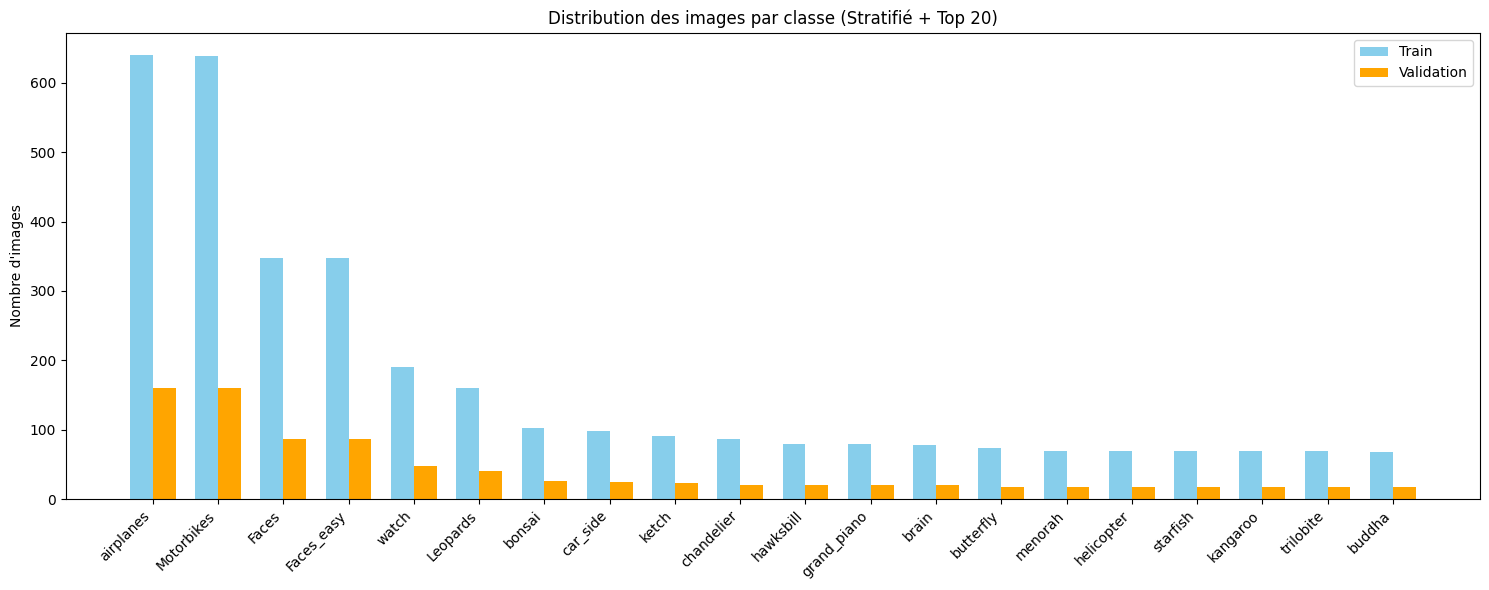

In [7]:
# Transformation pour le train : Augmentation du dataset
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(config['data']['img_size'], scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.Lambda(lambda x: x.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformation "clean" pour la validation
val_transforms = transforms.Compose([
    transforms.Resize((config['data']['img_size'], config['data']['img_size'])),
    transforms.Lambda(lambda x: x.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 2. Chargement du Dataset "Brut" ---
full_dataset = datasets.Caltech101(root=config['data']['root'], download=True, transform=None)

# --- 3. Split Stratifié : pour équilibrer le nombres d'images par classe dans les datasets de train et de validation ---
targets = full_dataset.y
train_idx, val_idx = train_test_split(
    np.arange(len(targets)),
    test_size=config['data']['val_split'],
    shuffle=True,
    stratify=targets,
    random_state=42
)

# Création des Subsets (qui contiennent juste les indices pour l'instant)
train_subset = Subset(full_dataset, train_idx)
val_subset = Subset(full_dataset, val_idx)

# --- 4. Application des transformations distinctes ---
class MapDataset(Dataset):
    """
    Cette classe prend un Subset et lui applique une transformation spécifique.
    """
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.dataset[index]
        # On applique la transformation spécifique (Train ou Val)
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.dataset)

# On enveloppe nos subsets avec la bonne transformation
train_dataset = MapDataset(train_subset, train_transforms)
val_dataset = MapDataset(val_subset, val_transforms)

train_size = len(train_dataset)
val_size = len(val_dataset)
num_classes = len(full_dataset.categories)

print(f"Classes: {num_classes}")
print(f"Images d'entraînement: {train_size}, Images de validation: {val_size}")


# --- Création du WeightedRandomSampler ---
# Objectif : Donner plus de poids aux classes rares pendant l'entraînement

# a. Compter les classes UNIQUEMENT dans le train set
train_targets = np.array(targets)[train_idx] # On filtre les targets pour n'avoir que ceux du train
class_counts = Counter(train_targets)

# b. Calculer le poids inverse (Moins il y a d'images, plus le poids est lourd)
# Exemple : si classe A a 10 images, poids = 1/10. Si classe B a 1000 images, poids = 1/1000.
class_weights = {cls: 1.0/count for cls, count in class_counts.items()}

# c. Assigner un poids à chaque IMAGE du dataset d'entraînement
sample_weights = [class_weights[label] for label in train_targets]

# d. Créer le sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True # Important pour pouvoir repiocher les images rares
)


dataloaders = {
    'train': DataLoader(
        train_dataset,
        batch_size=config['data']['batch_size'],
        sampler=sampler,  # <--- On injecte un sampler
        shuffle=False,    # <--- Faux car on utilise un sampler
        num_workers=2
    ),
    'val': DataLoader(
        val_dataset,
        batch_size=config['data']['batch_size'],
        shuffle=False,
        num_workers=2
    )
}
dataset_sizes = {'train': train_size, 'val': val_size}


# --- 5. Exploration des données ---

def analyze_subset(subset, full_ds, name="Dataset"):
    """
    Analyse la distribution des classes en gérant MapDataset et Subset.
    """
    # 1. Récupération des indices (Gestion du wrapper MapDataset)
    if hasattr(subset, 'dataset') and hasattr(subset.dataset, 'indices'):
        indices = subset.dataset.indices
    elif hasattr(subset, 'indices'):
        indices = subset.indices
    else:
        print(f"Erreur: Impossible de trouver les indices pour {name}")
        return {}

    # 2. Récupération des labels
    all_labels = np.array(full_ds.y)
    subset_labels = all_labels[indices]

    # 3. Comptage
    count_dict = Counter(subset_labels)

    # Statistiques basiques
    if len(count_dict) > 0:
        min_imgs = min(count_dict.values())
        max_imgs = max(count_dict.values())
        avg_imgs = np.mean(list(count_dict.values()))
    else:
        min_imgs = max_imgs = avg_imgs = 0

    print(f"\n--- Analyse de {name} ---")
    print(f"Nombre total d'images : {len(subset)}")
    print(f"Nombre de classes présentes : {len(count_dict)}")
    print(f"Images par classe -> Min: {min_imgs}, Max: {max_imgs}, Moy: {avg_imgs:.2f}")

    return count_dict

def plot_distribution(train_counts, val_counts, categories):
    sorted_indices = sorted(train_counts.keys(), key=lambda x: train_counts[x], reverse=True)
    top_n = 20
    top_indices = sorted_indices[:top_n]

    labels = [categories[i] for i in top_indices]
    train_vals = [train_counts[i] for i in top_indices]
    val_vals = [val_counts.get(i, 0) for i in top_indices]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(15, 6))
    plt.bar(x - width/2, train_vals, width, label='Train', color='skyblue')
    plt.bar(x + width/2, val_vals, width, label='Validation', color='orange')

    plt.ylabel('Nombre d\'images')
    plt.title(f'Distribution des images par classe (Stratifié + Top {top_n})')
    plt.xticks(x, labels, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Exécution de l'analyse
print("Analyse de la distribution...")
train_counts = analyze_subset(train_dataset, full_dataset, "Train Set")
val_counts = analyze_subset(val_dataset, full_dataset, "Validation Set")

plot_distribution(train_counts, val_counts, full_dataset.categories)

On définit ensuite une fonction d'entraînement qui prend en paramètre :
- Un modèle
- Un oprimiseur (descente de gradient)
- un nombre d'époques
- un nom de phase (expliqué plus bas)

Cette fonction implémente aussi un arrêt prématuré (early stopping) dans le cas où le score de validation commence à baisser au fur et à mesure de l'entraînement.

In [8]:
class EarlyStopping:
    """
    Stops training if validation loss doesn't improve after a given patience.
    """
    def __init__(self, patience=5, verbose=False, delta=0):
        """
        Args:
            patience (int): How many epochs to wait after last time val_loss improved.
            verbose (bool): If True, prints a message for each validation loss improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), 'checkpoint.pt')
        self.val_loss_min = val_loss

def run_training_phase(model, optimizer, scheduler, num_epochs, phase_name, patience=5):
    print(f"\n=== Démarrage {phase_name} ({num_epochs} époques) ===")
    print(f"--- Early Stopping Patience: {patience} ---")

    since = time.time()

    # Initialize Early Stopping
    early_stopping = EarlyStopping(patience=patience, verbose=True)

    history = {'acc': [], 'val_loss': []}

    for epoch in range(num_epochs):
        print(f'Époque {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # --- EARLY STOPPING CHECK (Only in Validation Phase) ---
            if phase == 'val':
                history['acc'].append(epoch_acc.item())
                history['val_loss'].append(epoch_loss)

                # Check early stopping
                early_stopping(epoch_loss, model)

                if early_stopping.early_stop:
                    print("Early stopping triggered!")
                    # Load the last best model (saved by the class)
                    model.load_state_dict(torch.load('checkpoint.pt'))

                    time_elapsed = time.time() - since
                    print(f'{phase_name} terminé en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s.')
                    return model, history

    # End of loops
    time_elapsed = time.time() - since
    print(f'{phase_name} terminé en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s.')

    # Ensure we return the best model found by early stopping
    model.load_state_dict(torch.load('checkpoint.pt'))

    return model, history

### Choix du modèle

Le modèle choisi est ResNet18, utilisé pour la classification d'images, et suffisamment ergonomique (18 couches de profondeur uniquement).

### Choix de l'optimiseur

On choisit ADAM (Adaptative Moment Estimation) qui permet de calculer un taux d'apprentissage adapté pour chaque poids (au lieu d'être fixé)

Cela est utile car les couches d'un réseau convolutionnel n'apprennent pas à la même vitesse. ADAM gère cela.

Aussi, nos batchs sont artificiellement modifiés, ce qui peut rendre les gradient plus instables. ADAM lisse ces fluctuations.

Enfin, Caltech-101 est un petit dataset, et la rapidité de convergence d'ADAM est un atout. Cela fait donc d'ADAM un choix particulièrement adapté à notre problème.

On entraîne maintenant notre modèle sur 3 époques en ne modifiant que la tête du modèle. Cela permet de voir comment le modèle évolue et de faire des modifications ensuite.

In [9]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 1. Freeze the Backbone
for param in model.parameters():
    param.requires_grad = False

# 2. Modify the Head with Regularization (Dropout)
# We replace the final fully connected layer.
num_ftrs = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs, num_classes)
)

model = model.to(device)

# --- 7. PHASE TEST : 3 époques

# B. Config Optimizer with Regularization (Weight Decay)
# Note: We only optimize parameters that require grad (the head)
criterion = nn.CrossEntropyLoss()

optimizer_step1 = optim.Adam(
    model.fc.parameters(),
    lr=float(config['phase_test']['lr']),
    weight_decay=1e-4
)

scheduler_step1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_step1,
    T_max=config['phase_test']['epochs']
)

# D. Exécution de la phase test
model, history1 = run_training_phase(
    model,
    optimizer_step1,
    scheduler_step1,
    config['phase_test']['epochs'],
    "PHASE 1 (Tête seulement)",
    patience=5
)


=== Démarrage PHASE 1 (Tête seulement) (3 époques) ===
--- Early Stopping Patience: 5 ---
Époque 1/3
----------
train Loss: 3.9090 Acc: 0.1678
val Loss: 2.3252 Acc: 0.6866
Validation loss decreased (inf --> 2.325178).  Saving model ...
Époque 2/3
----------
train Loss: 2.3657 Acc: 0.5266
val Loss: 1.4263 Acc: 0.8099
Validation loss decreased (2.325178 --> 1.426252).  Saving model ...
Époque 3/3
----------
train Loss: 1.8885 Acc: 0.6330
val Loss: 1.2593 Acc: 0.8203
Validation loss decreased (1.426252 --> 1.259293).  Saving model ...
PHASE 1 (Tête seulement) terminé en 2m 22s.


L'entraînement fonctionne bien pour 3 époques. Il convient à présent de mettre en place une stratégie solide d'entraînement et de validation.

# M3 : Optimisation et régularisation

On met à présent en place une stratégie en 2 phases :
1. Phase 1 :
- couches gelées sauf la tête
- pas d'apprentissage à 1.e-3
- 15 époques

2. Phase 2:
- Couches dégelées
- pas d'apprentissage à 1.e-5 (pour éviter de dérégler les autres couches)
- 10 époques

Ces 2 phases permettent dans un premier d'entraîner uniquement la tête, pour fine-tuner le modèle, et ensuite on dégèle les couches en baissant le pas d'apprentissage, afin d'améliorer l'exactitude et apporter de légères modifications à toutes les couches, sans casser le modèle.

### Régularisation :
- Weight decay (Régularisation L2)
- Dropout
- Learning rate scheduling (Cosine annealing strategy)

On lance ensuite l'entraînement des 2 phases

In [11]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 1. Freeze the Backbone
for param in model.parameters():
    param.requires_grad = False

# 2. Modify the Head with Regularization (Dropout)
# We replace the final fully connected layer.
num_ftrs = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs, num_classes)
)

model = model.to(device)

# --- 7. PHASE 1: Training the Head Only ---

# B. Config Optimizer with Regularization (Weight Decay)
# Note: We only optimize parameters that require grad (the head)
criterion = nn.CrossEntropyLoss()

optimizer_step1 = optim.Adam(
    model.fc.parameters(),
    lr=float(config['phase1']['lr']),
    weight_decay=1e-4
)

# C. Learning Rate Scheduler
scheduler_step1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_step1,
    T_max=config['phase1']['epochs']
)

# D. Run Phase 1
model, history1 = run_training_phase(
    model,
    optimizer_step1,
    scheduler_step1,
    config['phase1']['epochs'],
    "PHASE 1 (Tête seulement)",
    patience=5
)


=== Démarrage PHASE 1 (Tête seulement) (15 époques) ===
--- Early Stopping Patience: 5 ---
Époque 1/15
----------
train Loss: 3.8710 Acc: 0.1676
val Loss: 2.3272 Acc: 0.6953
Validation loss decreased (inf --> 2.327206).  Saving model ...
Époque 2/15
----------
train Loss: 2.2795 Acc: 0.5328
val Loss: 1.2915 Acc: 0.7880
Validation loss decreased (2.327206 --> 1.291474).  Saving model ...
Époque 3/15
----------
train Loss: 1.6062 Acc: 0.6624
val Loss: 0.9053 Acc: 0.8445
Validation loss decreased (1.291474 --> 0.905311).  Saving model ...
Époque 4/15
----------
train Loss: 1.2806 Acc: 0.7261
val Loss: 0.7491 Acc: 0.8289
Validation loss decreased (0.905311 --> 0.749097).  Saving model ...
Époque 5/15
----------
train Loss: 1.0940 Acc: 0.7631
val Loss: 0.6769 Acc: 0.8445
Validation loss decreased (0.749097 --> 0.676927).  Saving model ...
Époque 6/15
----------
train Loss: 0.9786 Acc: 0.7850
val Loss: 0.6084 Acc: 0.8715
Validation loss decreased (0.676927 --> 0.608442).  Saving model ...
É

In [12]:
# --- 8. PHASE 2: Fine-Tuning (Unfreezing) ---

print("\n--- Setup for Phase 2: Fine-Tuning ---")

# 1. Unfreeze specific layers (or all layers)
# Unfreezing the last residual block (layer4) and the fc layer
for name, child in model.named_children():
    if name in ['layer4', 'fc']:
        for param in child.parameters():
            param.requires_grad = True
    else:
        # Keep earlier layers frozen (optional, depends on dataset size)
        for param in child.parameters():
            param.requires_grad = False

# 2. Update Optimizer for Phase 2
# We use a lower learning rate for the backbone to avoid destroying learned features
optimizer_step2 = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': config['phase1']['lr'] / 10}, # Lower LR for backbone
    {'params': model.fc.parameters(), 'lr': config['phase1']['lr']}           # Standard LR for head
], weight_decay=1e-4) # Maintain Weight Decay

# 3. Reset Scheduler for Phase 2
scheduler_step2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_step2,
    T_max=10 # Assuming 10 epochs for fine-tuning
)

model, acc2 = run_training_phase(
    model,
    optimizer_step2,
    scheduler_step2,
    num_epochs=10,
    phase_name="PHASE 2 (Fine-Tuning)"
)


--- Setup for Phase 2: Fine-Tuning ---

=== Démarrage PHASE 2 (Fine-Tuning) (10 époques) ===
--- Early Stopping Patience: 5 ---
Époque 1/10
----------
train Loss: 0.5195 Acc: 0.8685
val Loss: 0.3137 Acc: 0.9038
Validation loss decreased (inf --> 0.313732).  Saving model ...
Époque 2/10
----------
train Loss: 0.2809 Acc: 0.9274
val Loss: 0.2393 Acc: 0.9355
Validation loss decreased (0.313732 --> 0.239288).  Saving model ...
Époque 3/10
----------
train Loss: 0.2125 Acc: 0.9428
val Loss: 0.2145 Acc: 0.9395
Validation loss decreased (0.239288 --> 0.214484).  Saving model ...
Époque 4/10
----------
train Loss: 0.1455 Acc: 0.9644
val Loss: 0.2045 Acc: 0.9441
Validation loss decreased (0.214484 --> 0.204499).  Saving model ...
Époque 5/10
----------
train Loss: 0.1161 Acc: 0.9736
val Loss: 0.1976 Acc: 0.9453
Validation loss decreased (0.204499 --> 0.197572).  Saving model ...
Époque 6/10
----------
train Loss: 0.0939 Acc: 0.9797
val Loss: 0.1961 Acc: 0.9435
Validation loss decreased (0.1975

L'entraînement terminé, on sauvegarde le meilleur modèle :

In [13]:
torch.save(model.state_dict(), os.path.join(config['output_dir'], 'final_resnet18_caltech_finetuned.pth'))


# M4 Analyse et étude

On observe les résultats suivants lorsqu'on effectue des changements :

| Situation | Positif | Négatif |
| --------- | --------- | --------- |
| lr à 1.e-3 et pas de gel des couches  | Entraînement fonctionnel  | Exactitude commence à 7% + oubli des paramètres initiaux  |
| Dataloader non stratifié, non équilibré et non augmenté | Exactitude à 95%  | Certaines classes complètement délaissées (0% d'exactitude)  |
| lr à 1.e-4 en phase 1 et à 1.e-6 en phase 2 | Entraînement qui évite mieux les perturbations majeures | Très lent. 1re phase finit à 71.7% d'exactitude, 2e phase finit à 74% |

Cela démontre ainsi la pertinence des choix que l'on a faits


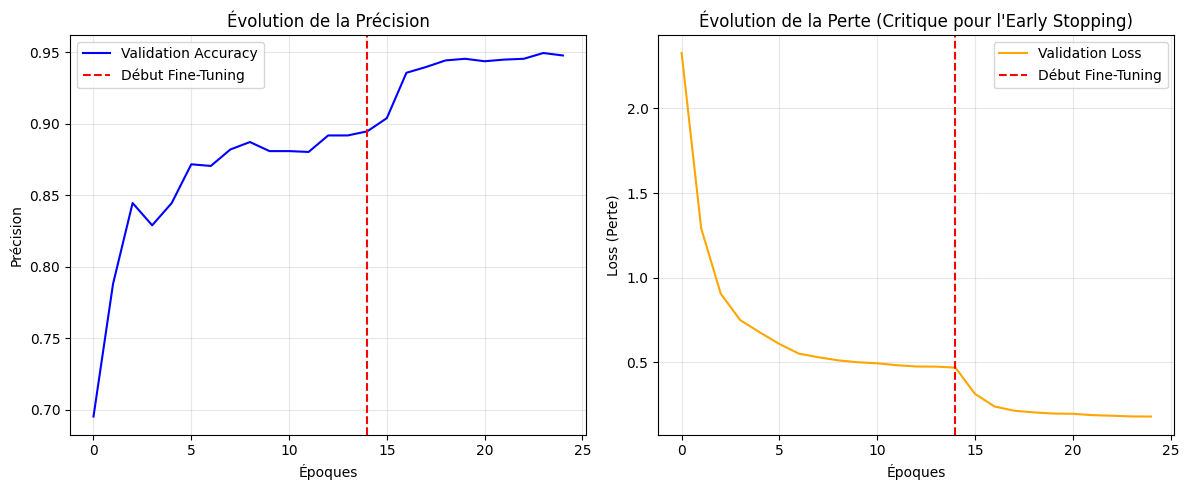

In [14]:
# 1. Extraction des données des dictionnaires
# history1 et history2 sont des dicts : {'acc': [...], 'val_loss': [...]}
acc_total = history1['acc'] + acc2['acc']
loss_total = history1['val_loss'] + acc2['val_loss']

# 2. Création du graphique (2 sous-graphiques : Accuracy et Loss)
plt.figure(figsize=(12, 5))

# --- GRAPHIQUE 1 : PRÉCISION (ACCURACY) ---
plt.subplot(1, 2, 1)
plt.plot(acc_total, label='Validation Accuracy', color='blue')
# Ligne rouge verticale pour marquer la transition Phase 1 -> Phase 2
plt.axvline(x=len(history1['acc']) - 1, color='red', linestyle='--', label='Début Fine-Tuning')
plt.xlabel('Époques')
plt.ylabel('Précision')
plt.title('Évolution de la Précision')
plt.legend()
plt.grid(True, alpha=0.3)

# --- GRAPHIQUE 2 : PERTE (LOSS) ---
plt.subplot(1, 2, 2)
plt.plot(loss_total, label='Validation Loss', color='orange')
# Ligne rouge verticale
plt.axvline(x=len(history1['val_loss']) - 1, color='red', linestyle='--', label='Début Fine-Tuning')
plt.xlabel('Époques')
plt.ylabel('Loss (Perte)')
plt.title('Évolution de la Perte (Critique pour l\'Early Stopping)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

On voit ici tout l'intérêt de la méthodologie que l'on a employée.

La 1re phase permet d'entraîner la tête, afin d'obtenir une base solide qui arrive à **90% d'exactitude** globale. Ensuite, la phase 2 permet d'entraîner tout le modèle lentement, ce qui nous permet d'obtenir une **exactitude de 95%.**

### Evaluation :
On utilise à présent notre modèle pour l'évaluer et obtenir des métriques diverses, comme la précision, le rappel, la matrice de confusion.

In [15]:
def evaluate_model(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []

    # On s'assure que le modèle est sur le bon device
    model = model.to(device)

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device) # Important pour la comparaison si besoin

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred

Génération du rapport d'évaluation...
Accuracy Globale: 0.9476

Rapport de Classification (Complet) :
                 precision    recall  f1-score   support

          Faces       0.98      1.00      0.99        87
     Faces_easy       1.00      0.98      0.99        87
       Leopards       1.00      1.00      1.00        40
     Motorbikes       0.99      1.00      1.00       160
      accordion       1.00      1.00      1.00        11
      airplanes       1.00      0.99      1.00       160
         anchor       0.88      0.88      0.88         8
            ant       0.73      1.00      0.84         8
         barrel       1.00      1.00      1.00         9
           bass       1.00      0.73      0.84        11
         beaver       0.90      1.00      0.95         9
      binocular       0.88      1.00      0.93         7
         bonsai       0.96      1.00      0.98        26
          brain       0.90      0.95      0.93        20
   brontosaurus       0.90      1.00      

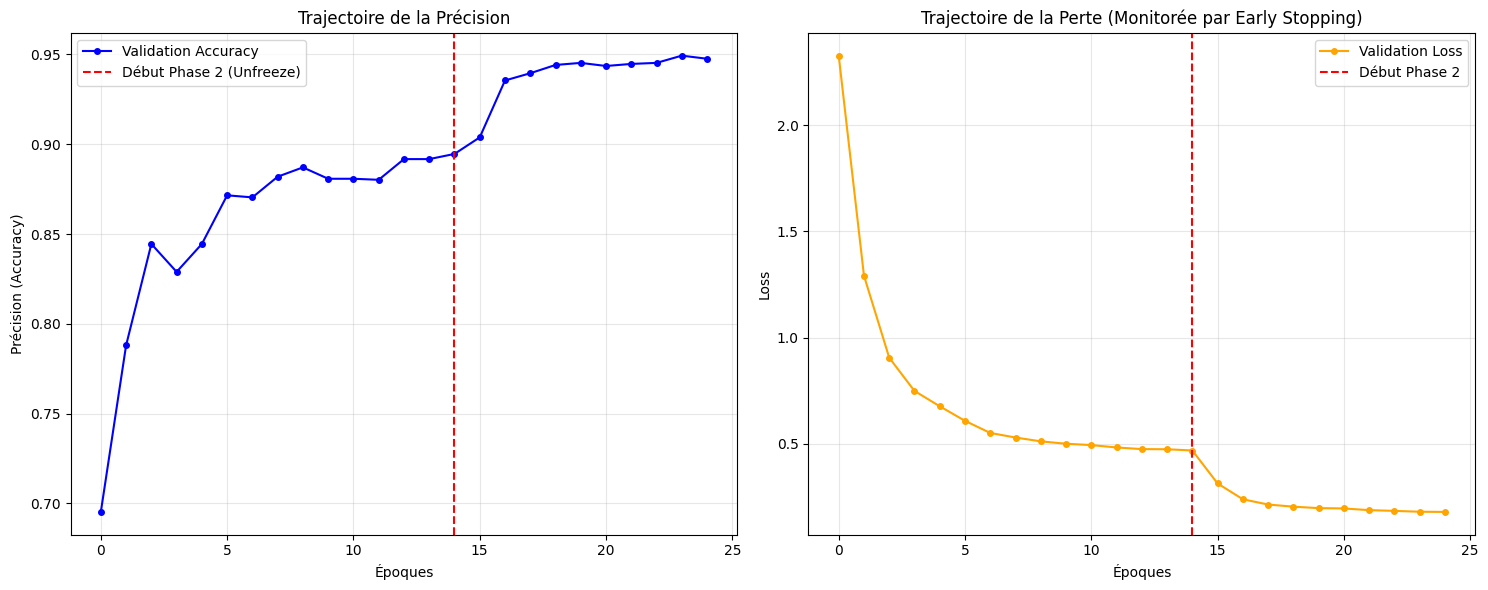

In [18]:
class_names = full_dataset.categories

# 1. Récupération des prédictions (inchangé)
print("Génération du rapport d'évaluation...")
# Assurez-vous que le modèle est sur le bon device (CPU ou GPU)
model.eval()
y_true, y_pred = evaluate_model(model, dataloaders['val'])

# 2. Affichage des métriques textuelles (inchangé)
print(f"Accuracy Globale: {accuracy_score(y_true, y_pred):.4f}")
print("\nRapport de Classification (Complet) :")

# On génère une liste d'indices pour forcer le mapping correct
all_labels = list(range(len(class_names)))

print(classification_report(y_true, y_pred,
                            target_names=class_names,
                            labels=all_labels))

# --- 3. VISUALISATION MISE À JOUR (Gestion des Dictionnaires) ---

# Attention : On suppose que vos variables s'appellent history1 et history2
# suite à la modification précédente.
acc_total = history1['acc'] + acc2['acc']
loss_total = history1['val_loss'] + acc2['val_loss']

# On crée une figure plus large pour mettre les 2 graphiques côte à côte
plt.figure(figsize=(15, 6))

# --- GRAPHIQUE A : PRÉCISION (ACCURACY) ---
plt.subplot(1, 2, 1)
plt.plot(acc_total, label='Validation Accuracy', marker='o', color='blue', markersize=4)

# Ligne rouge de séparation
split_epoch = len(history1['acc']) - 1
plt.axvline(x=split_epoch, color='r', linestyle='--', label='Début Phase 2 (Unfreeze)')

plt.xlabel('Époques')
plt.ylabel('Précision (Accuracy)')
plt.title('Trajectoire de la Précision')
plt.legend()
plt.grid(True, alpha=0.3)

# --- GRAPHIQUE B : PERTE (LOSS) ---
plt.subplot(1, 2, 2)
plt.plot(loss_total, label='Validation Loss', marker='o', color='orange', markersize=4)

# Ligne rouge de séparation
plt.axvline(x=split_epoch, color='r', linestyle='--', label='Début Phase 2')

plt.xlabel('Époques')
plt.ylabel('Loss')
plt.title('Trajectoire de la Perte (Monitorée par Early Stopping)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Cela nous permet d'obtenir des métriques intéressantes pour chaque classe.

Ces métriques sont satisfaisantes pour la plupart, avec beaucoup de classes atteignant 100% !

Cependant, il est important de noter que nous étions limités par la petite taille du dataset, ce qui fait qu'on obtient également des classes avec 50% d'exactitude (illustrant les cas où on a assez peu d'images dans le dataset de validation pour une classe).


Nous allons maintenant étudier les performances de notre modèle plus en détail en affichant notamment les différentes métriques par classe, une matrice de confusion et un leaderboard des classes les mieux / les moins bien prédites.

In [19]:
def generate_rich_evaluation(model, dataloader, class_names, output_dir="outputs"):
    """
    Génère un rapport d'évaluation complet inspiré de evaluate.py :
    - JSON global
    - CSV par classe
    - Matrice de confusion (Image)
    - Leaderboard des performances (Image)
    """

    # Création du dossier de sortie
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    print("1. Calcul des prédictions...")
    # Réutilisation de votre logique d'évaluation existante
    model.eval()
    model = model.to(device)

    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Conversion en numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print("2. Génération des rapports statistiques...")

    # --- A. Classification Report (Metrics) ---
    # Note : On inclut labels=... pour éviter l'erreur si certaines classes sont absentes du val set
    all_labels = list(range(len(class_names)))

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        labels=all_labels,
        output_dict=True,
        zero_division=0
    )

    # Création du DataFrame par classe
    # On filtre pour ne garder que les classes (on exclut accuracy, macro avg, etc. pour le CSV)
    per_class_df = pd.DataFrame(report_dict).transpose()
    per_class_df_only_classes = per_class_df.loc[class_names]

    # Sauvegarde CSV
    csv_path = out_path / "per_class_metrics.csv"
    per_class_df_only_classes.to_csv(csv_path, float_format="%.4f")

    # Sauvegarde JSON Global
    macro_avg = report_dict["macro avg"]
    weighted_avg = report_dict["weighted avg"]

    stats = {
        "val_acc": report_dict["accuracy"],
        "macro_precision": macro_avg["precision"],
        "macro_recall": macro_avg["recall"],
        "macro_f1": macro_avg["f1-score"],
        "weighted_precision": weighted_avg["precision"],
        "weighted_recall": weighted_avg["recall"],
        "weighted_f1": weighted_avg["f1-score"],
        "num_samples": int(len(y_true))
    }

    with open(out_path / "eval.json", "w") as f:
        json.dump(stats, f, indent=2)

    print("3. Génération des visualisations (Images)...")
    sns.set_theme(style="whitegrid")

    # --- B. Matrice de Confusion ---
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)

    # Pour Caltech101 (101 classes), la matrice est géante.
    # On ajuste la taille de la figure dynamiquement.
    figsize_cm = max(10, len(class_names) * 0.3)
    fig, ax = plt.subplots(figsize=(figsize_cm, figsize_cm))

    sns.heatmap(
        cm,
        annot=True if len(class_names) < 30 else False, # On enlève les chiffres si trop de classes pour lisibilité
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={"shrink": 0.75},
        ax=ax,
        square=True
    )
    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    fig.tight_layout()
    fig.savefig(out_path / "confusion_matrix.png", dpi=200)
    plt.close(fig)

    # --- C. Leaderboard (Barplot Precision/Recall/F1) ---
    # Préparation des données pour Seaborn (Melt)
    leaderboard_df = (
        per_class_df_only_classes[["precision", "recall", "f1-score"]]
        .reset_index()
        .rename(columns={"index": "class"})
        .melt(id_vars="class", var_name="metric", value_name="score")
    )

    # Hauteur dynamique selon le nombre de classes pour que tout soit lisible
    # Caltech101 a besoin de beaucoup de hauteur !
    height = max(5, len(class_names) * 0.3)

    fig, ax = plt.subplots(figsize=(10, height))
    sns.barplot(
        data=leaderboard_df,
        x="score",
        y="class",
        hue="metric",
        palette="viridis",
        ax=ax,
        orient="h"
    )
    ax.set_xlim(0, 1)
    ax.set_xlabel("Score")
    ax.set_ylabel("Class")
    ax.set_title("Per-class Metrics Leaderboard")
    ax.legend(title="Metric", loc="lower right")

    # On inverse l'axe Y pour avoir l'ordre alphabétique de haut en bas
    # (ou on pourrait trier par score F1 pour voir les meilleures classes en premier)
    # ax.invert_yaxis()

    fig.tight_layout()
    fig.savefig(out_path / "leaderboard.png", dpi=200)
    plt.close(fig)

    print(f"✅ Terminé ! Résultats sauvegardés dans : {out_path.absolute()}")
    print(f"  - eval.json")
    print(f"  - per_class_metrics.csv")
    print(f"  - confusion_matrix.png")
    print(f"  - leaderboard.png")

# --- Lancement de l'évaluation ---
generate_rich_evaluation(model, dataloaders['val'], full_dataset.categories, output_dir="outputs")

1. Calcul des prédictions...
2. Génération des rapports statistiques...
3. Génération des visualisations (Images)...
✅ Terminé ! Résultats sauvegardés dans : /content/dl_project/starters/cv-project-starter/cv-project/outputs
  - eval.json
  - per_class_metrics.csv
  - confusion_matrix.png
  - leaderboard.png


Maintenant que nous avons généré ces fichiers de résultat, nous les affichons dans le notebook.

📊 MÉTRIQUES GLOBALES


,val_acc,macro_f1,weighted_f1,num_samples
0,0.9476,0.9201,0.9472,1736.0000



🏆 TOP & FLOP CLASSES (Basé sur F1-Score)
✅ Les 5 Meilleures classes :


,precision,recall,f1-score,support
Leopards,1.000000,1.000000,1.000000,40.000000
accordion,1.000000,1.000000,1.000000,11.000000
car_side,1.000000,1.000000,1.000000,25.000000
buddha,1.000000,1.000000,1.000000,17.000000
barrel,1.000000,1.000000,1.000000,9.000000


❌ Les 5 Moins bonnes classes :


,precision,recall,f1-score,support
crayfish,0.769200,0.714300,0.740700,14.000000
platypus,0.800000,0.571400,0.666700,7.000000
lotus,0.777800,0.538500,0.636400,13.000000
crocodile,0.666700,0.600000,0.631600,10.000000
water_lilly,0.500000,0.857100,0.631600,7.000000



📈 VISUALISATIONS GÉNÉRÉES


### 1. Leaderboard des classes

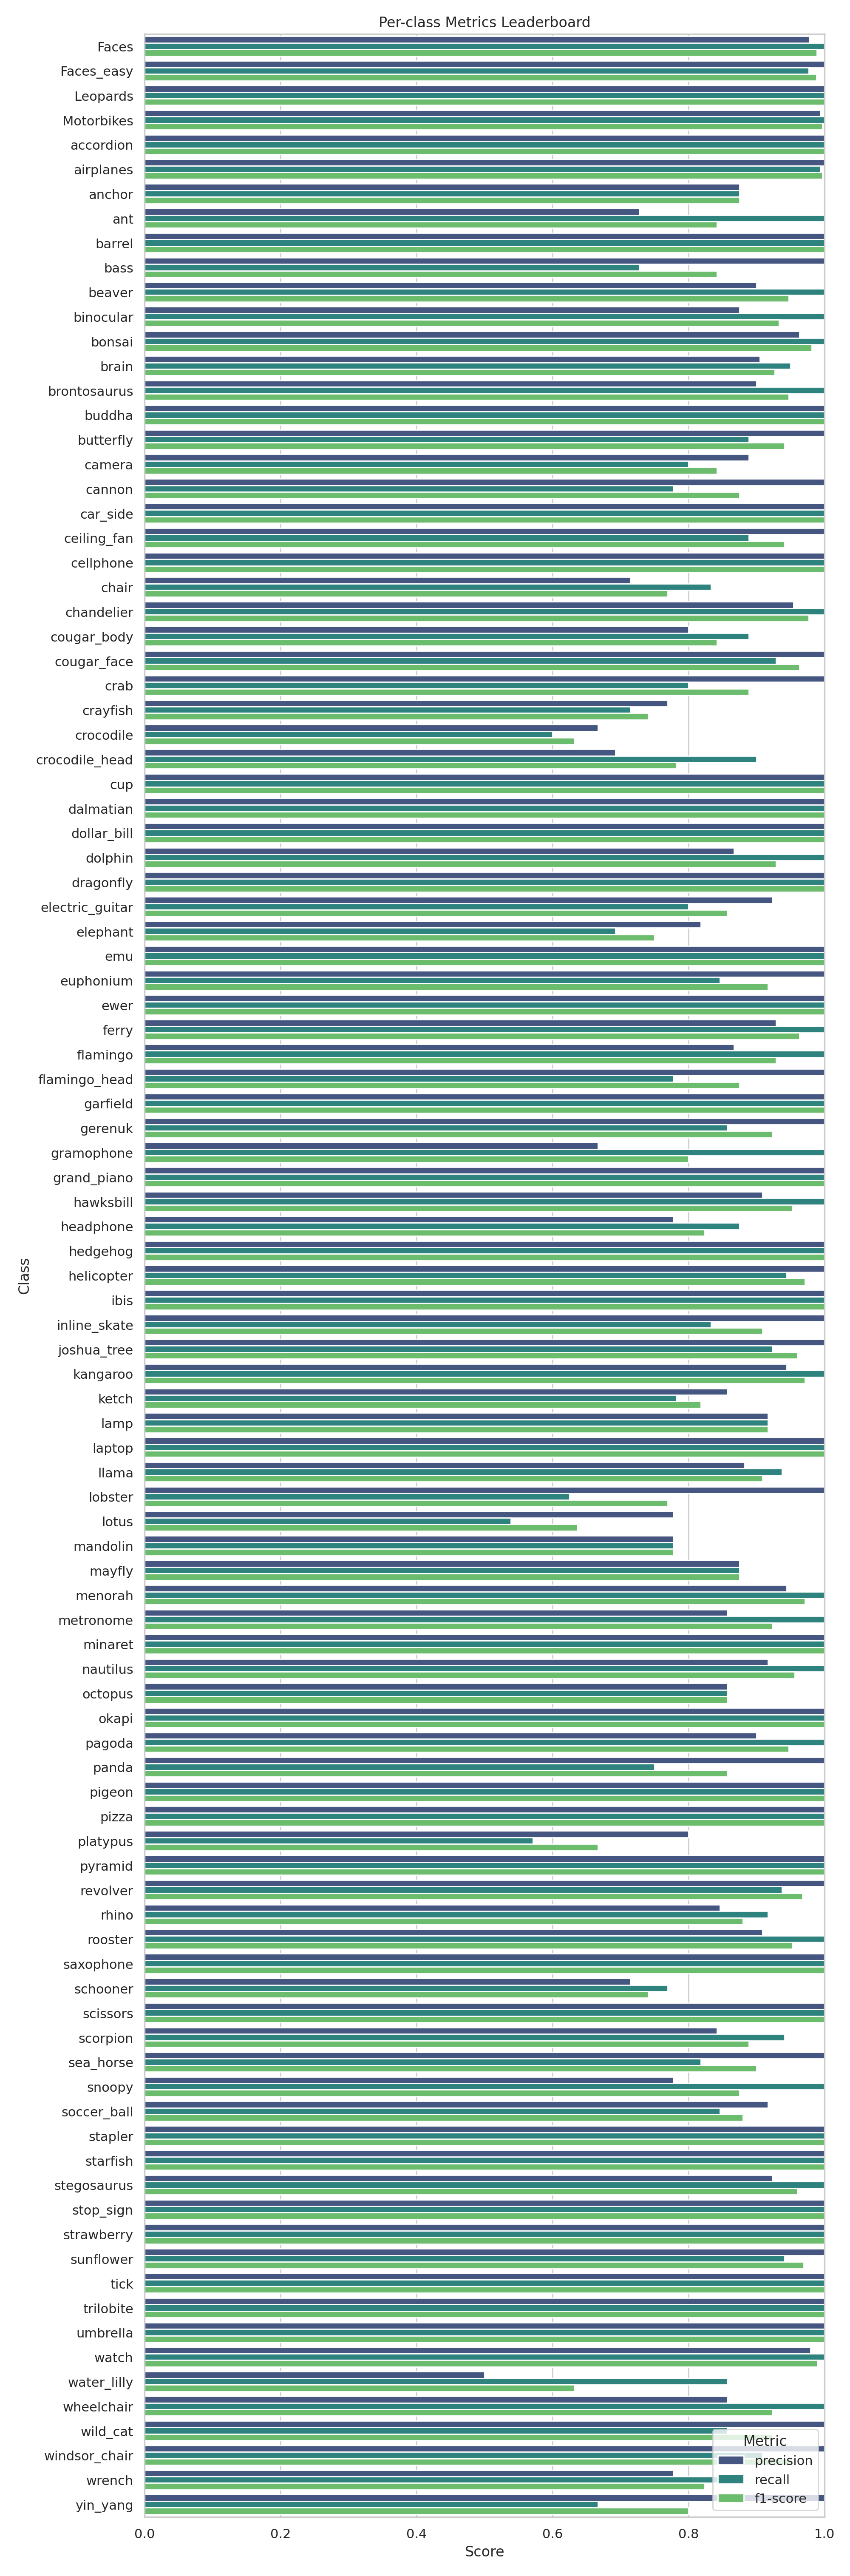

### 2. Matrice de Confusion

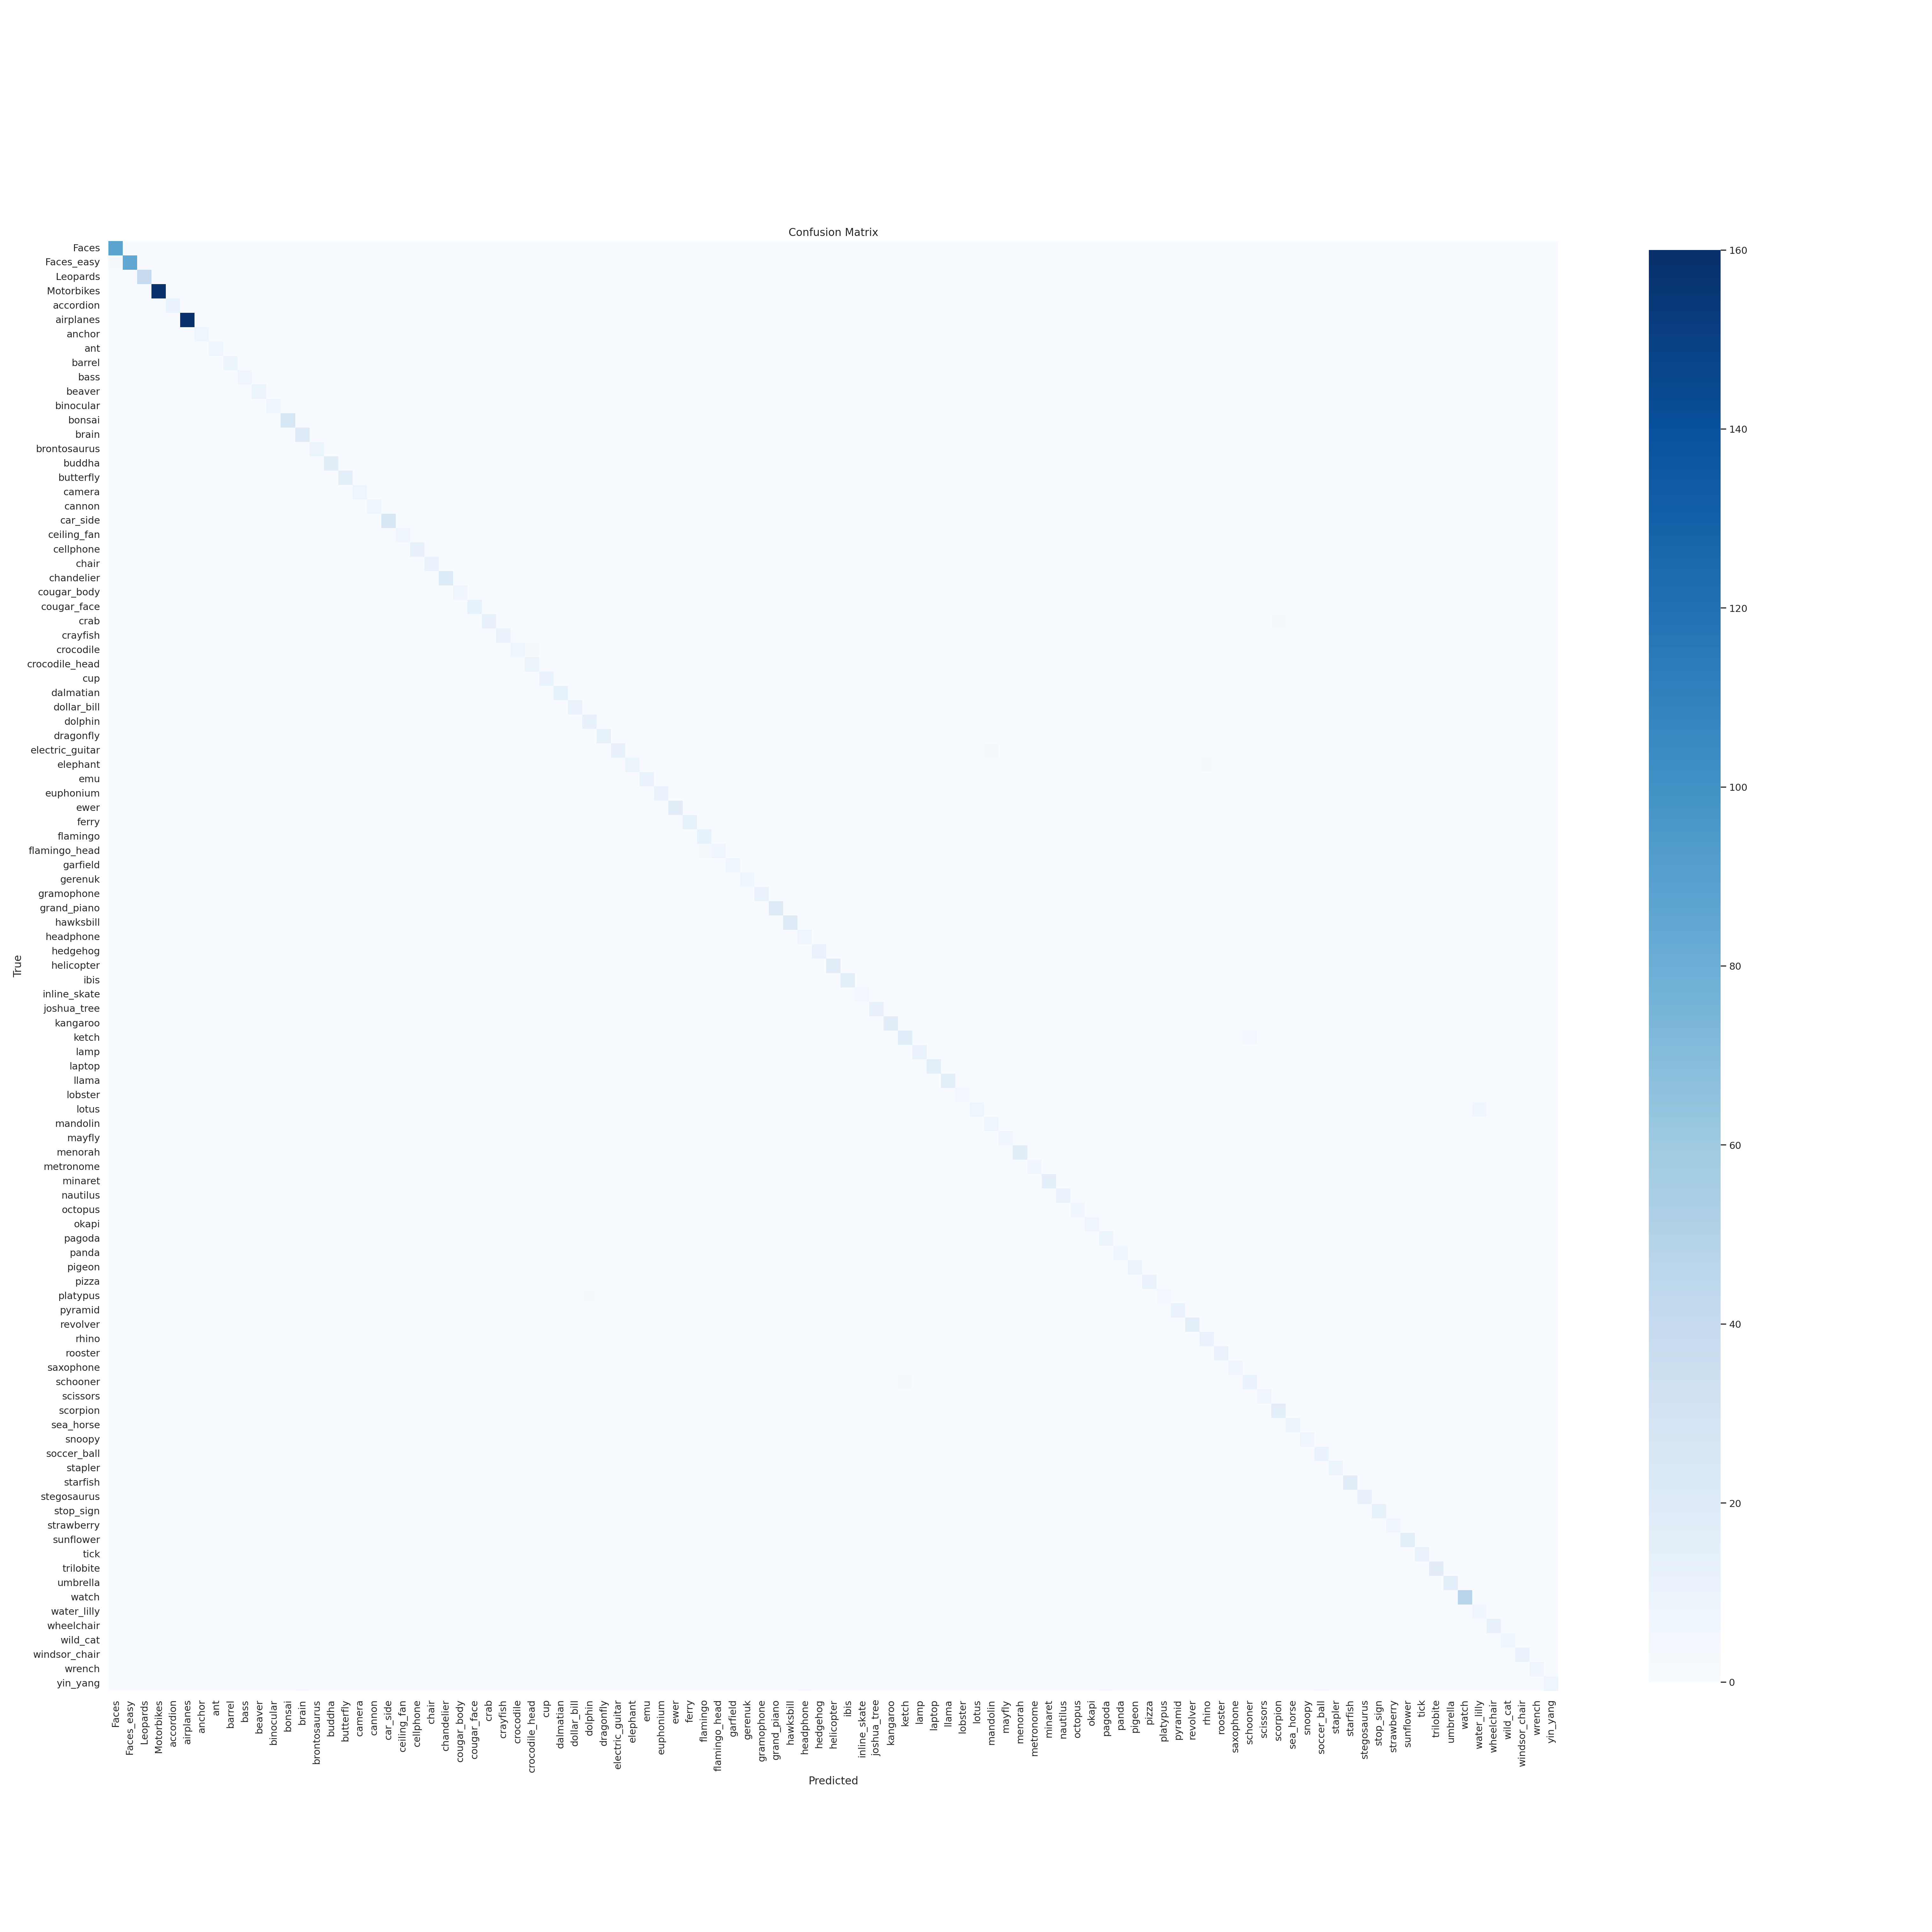

In [20]:
output_dir = "outputs"

# --- 1. Affichage des Métriques Globales (JSON) ---
print("📊 MÉTRIQUES GLOBALES")
print("="*30)
with open(f"{output_dir}/eval.json", "r") as f:
    metrics = json.load(f)

# On affiche sous forme de petit tableau propre
global_df = pd.DataFrame([metrics], columns=["val_acc", "macro_f1", "weighted_f1", "num_samples"])
display(global_df.style.format("{:.4f}"))

# --- 2. Analyse par Classe (CSV) ---
print("\n🏆 TOP & FLOP CLASSES (Basé sur F1-Score)")
print("="*30)
df_classes = pd.read_csv(f"{output_dir}/per_class_metrics.csv", index_col=0)

# Tri par F1-score décroissant
df_sorted = df_classes.sort_values(by="f1-score", ascending=False)

print("✅ Les 5 Meilleures classes :")
display(df_sorted.head(5).style.background_gradient(cmap="Greens", subset=["f1-score"]))

print("❌ Les 5 Moins bonnes classes :")
display(df_sorted.tail(5).style.background_gradient(cmap="Reds_r", subset=["f1-score"]))

# --- 3. Visualisations (Images) ---
print("\n📈 VISUALISATIONS GÉNÉRÉES")
print("="*30)

display(Markdown("### 1. Leaderboard des classes"))
display(Image(filename=f"{output_dir}/leaderboard.png", width=800))

display(Markdown("### 2. Matrice de Confusion"))
display(Image(filename=f"{output_dir}/confusion_matrix.png", width=600))

Avec la méthode que l'on a utilisé, on obtient un modèle puissant, qui n'ignore pas de classes (minimum d'exactitude à 50%, puis de 67%, et score F1 minimum de 63%.)

Cela démontre l'efficacité de la stratégie des poids et de la stratification des données dans le dataloader.

La matrice de confusion est difficilement interprétable compte tenu du nombre de classes, mais on distingue bien une diagonale correspondant aux prédictions vraies de notre modèle.

Cependant, il est vrai que ce n'est pas forcément idéal. Un score inférieur à 70% pour certaines classes n'est pas forcément très bon. Une hypothèse majeure qui explique cela est le manque de données et de diversité, qui pourrait permettre s'il était comblé d'obtenir de meilleures performances.

Également, nous aurions pu obtenir de meilleurs performances en utilisant des modèles plus puissants comme **ResNet50** ou **ResNet101**, mais cela aurait pris beaucoup plus de temps pour entraîner le modèle.